# Improving Embeddings with Biased Random Walks in Node2Vec

In [1]:
!pip install -q node2vec==0.4.6
!pip install -qI gensim==4.3.0

/Users/namun/Dev/gnn-2026-2-jejunu0class/.venv/lib/python3.10/site-packages/networkx/drawing/nx_pylab.py:433: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


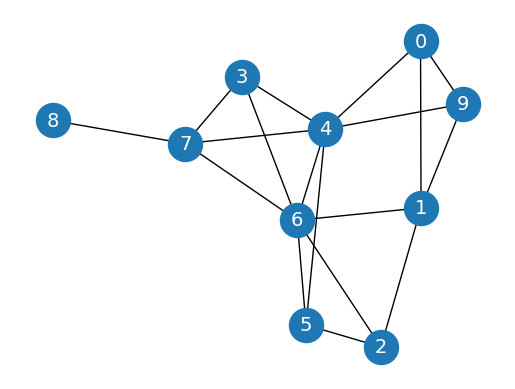

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

# Create graph
G = nx.erdos_renyi_graph(10, 0.3, seed=1, directed=False)

# Plot graph
plt.figure()
plt.axis('off')
nx.draw_networkx(G,
                 pos=nx.spring_layout(G, seed=0),
                 node_size=600,
                 cmap='coolwarm',
                 font_size=14,
                 font_color='white'
                 )

In [3]:
import random
random.seed(0)
import numpy as np
np.random.seed(0)

def next_node(previous, current, p, q):
    alphas = []

    # Get the neighboring nodes
    neighbors = list(G.neighbors(current))
    
    # Calculate the appropriate alpha value for each neighbor
    for neighbor in neighbors:
        # Distance = 0: probability to return to the previous node
        if neighbor == previous:
            alpha = 1/p
        # Distance = 1: probability of visiting a local node
        elif G.has_edge(neighbor, previous):
            alpha = 1
        # Distance = 2: probability to explore an unknown node
        else:
            alpha = 1/q
        alphas.append(alpha)

    # Normalize the alpha values to create transition probabilities
    probs = [alpha / sum(alphas) for alpha in alphas]
    
    # Randomly select the new node based on the transition probabilities
    next = np.random.choice(neighbors, size=1, p=probs)[0]
    return next

In [4]:
def random_walk(start, length, p, q):
    walk = [start]
    
    for i in range(length):
        current = walk[-1]
        previous = walk[-2] if len(walk) > 1 else None
        next = next_node(previous, current, p, q)
        walk.append(next)
    
    return walk

In [5]:
random_walk(0, 8, p=1, q=1)

[0, 4, 7, 6, 4, 5, 4, 5, 6]

In [6]:
random_walk(0, 8, p=1, q=10)

[0, 9, 1, 9, 1, 9, 1, 0, 1]

In [7]:
random_walk(0, 8, p=10, q=1)

[0, 1, 9, 4, 7, 8, 7, 4, 6]

In [8]:
from gensim.models.word2vec import Word2Vec
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load dataset
G = nx.karate_club_graph()

# Process labels (Mr. Hi = 0, Officer = 1)
labels = []
for node in G.nodes:
    label = G.nodes[node]['club']
    labels.append(1 if label == 'Officer' else 0)

# Create a list of random walks
walks = []
for node in G.nodes:
    for _ in range(80):
        walks.append(random_walk(node, 10, 3, 2))

# Create and train Word2Vec for DeepWalk
node2vec = Word2Vec(walks,
                hs=1,   # Hierarchical softmax
                sg=1,   # Skip-gram
                vector_size=100,
                window=10,
                workers=2,
                min_count=1,
                seed=0)
node2vec.train(walks, total_examples=node2vec.corpus_count, epochs=30, report_delay=1)

# Create masks to train and test the model
train_mask = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24]
test_mask = [0, 1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 26, 27, 28, 29, 30, 31, 32, 33]
labels = np.array(labels)

# Train Node2Vec classifier
clf = RandomForestClassifier(random_state=0)
clf.fit(node2vec.wv[train_mask], labels[train_mask])

# Evaluate accuracy
y_pred = clf.predict(node2vec.wv[test_mask])
acc = accuracy_score(y_pred, labels[test_mask])
print(f'Node2Vec accuracy = {acc*100:.2f}%')

Node2Vec accuracy = 90.91%


In [2]:
from io import BytesIO
from urllib.request import urlopen
from zipfile import ZipFile

url = 'https://files.grouplens.org/datasets/movielens/ml-100k.zip'
with urlopen(url) as zurl:
    with ZipFile(BytesIO(zurl.read())) as zfile:
        zfile.extractall('.')

In [3]:
import pandas as pd

ratings = pd.read_csv('ml-100k/u.data', sep='\t', names=['user_id', 'movie_id', 'rating', 'unix_timestamp'])
ratings

,user_id,movie_id,rating,unix_timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596
...,...,...,...,...
99995,880,476,3,880175444
99996,716,204,5,879795543
99997,276,1090,1,874795795
99998,13,225,2,882399156


In [4]:
movies = pd.read_csv('ml-100k/u.item', sep='|', usecols=range(2), names=['movie_id', 'title'], encoding='latin-1')
movies

,movie_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)
...,...,...
1677,1678,Mat' i syn (1997)
1678,1679,B. Monkey (1998)
1679,1680,Sliding Doors (1998)
1680,1681,You So Crazy (1994)


In [5]:
# Only consider ratings with the highest score
ratings = ratings[ratings.rating >= 4]
ratings

,user_id,movie_id,rating,unix_timestamp
5,298,474,4,884182806
7,253,465,5,891628467
11,286,1014,5,879781125
12,200,222,5,876042340
16,122,387,5,879270459
...,...,...,...,...
99988,421,498,4,892241344
99989,495,1091,4,888637503
99990,806,421,4,882388897
99991,676,538,4,892685437


In [ ]:
from collections import defaultdict

pairs = defaultdict(int)

# Loop through the entire list of users
for group in ratings.groupby("user_id"): # group[0] is the user_id, group[1] is the DataFrame of that user's ratings
    # List of IDs of movies rated by the current user
    user_movies = list(group[1]["movie_id"]) # List of IDs of movies rated by the current user

    # Count every time two movies are seen together
    for i in range(len(user_movies)):
        for j in range(i+1, len(user_movies)):
            pairs[(user_movies[i], user_movies[j])] += 1 # Increment the count for the pair of movies (i, j)

In [9]:
import networkx as nx
# Create a networkx graph
G = nx.Graph()

# Try to create an edge between movies that are liked together
for pair in pairs:
    movie1, movie2 = pair
    score = pairs[pair]

    # The edge is only created when the score is high enough
    if score >= 20:
        G.add_edge(movie1, movie2, weight=score)

print("Total number of graph nodes:", G.number_of_nodes())
print("Total number of graph edges:", G.number_of_edges())

Total number of graph nodes: 410
Total number of graph edges: 14936


In [12]:
from node2vec import Node2Vec

node2vec = Node2Vec(G, dimensions=128, walk_length=20, num_walks=200, p=2, q=1, workers=1) # Create a Node2Vec model with specified parameters. 의미: Create a Node2Vec model that will learn 64-dimensional embeddings for the nodes in graph G. The random walks will have a length of 20, and 200 walks will be generated for each node. The parameters p and q control the likelihood of returning to the previous node or exploring new nodes during the random walks. The model will use 1 worker thread for training.
# 여기에서 dimension의 의미는 각 노드가 64차원의 벡터로 표현된다는 것입니다. walk_length는 각 랜덤 워크의 길이를 나타내며, num_walks는 각 노드에 대해 생성할 랜덤 워크의 수를 나타냅니다. p와 q는 랜덤 워크에서 이전 노드로 돌아갈 확률과 새로운 노드를 탐색할 확률을 조절하는 하이퍼파라미터입니다. workers는 모델 학습에 사용할 CPU 코어 수를 지정합니다.
# 최적 dimension은 실험적으로 결정해야 합니다. 일반적으로 64 또는 128 차원이 많이 사용되지만, 데이터의 복잡성과 크기에 따라 최적의 차원이 달라질 수 있습니다. 너무 낮은 차원은 정보 손실을 초래할 수 있고, 너무 높은 차원은 과적합을 유발할 수 있으므로 적절한 차원을 선택하는 것이 중요합니다.

model = node2vec.fit(window=10, min_count=1, batch_words=4) # Train the Node2Vec model using the generated random walks. The window parameter specifies the context size for the skip-gram model, min_count=1 ensures that all nodes are included in the training, and batch_words=4 controls the number of words (nodes) processed in each training batch.

Computing transition probabilities:   0%|          | 0/410 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 200/200 [00:40<00:00,  4.93it/s]


In [13]:
def recommend(movie):
    movie_id = str(movies[movies.title == movie].movie_id.values[0]) # Get the ID of the movie based on its title
    for id in model.wv.most_similar(movie_id)[:5]: # Get the 5 most similar movies to the input movie
        title = movies[movies.movie_id == int(id[0])].title.values[0] # Get the title of the recommended movie
        print(f'{title}: {id[1]:.2f}')

recommend('Star Wars (1977)') # Recommend movies similar to "Star Wars (1977)"

Toy Story (1995): 0.41
Return of the Jedi (1983): 0.40
Raiders of the Lost Ark (1981): 0.37
Silence of the Lambs, The (1991): 0.37
Godfather, The (1972): 0.34


# 사용자를 입력했을 때 그 사용자와 비슷한 취향의 영화 5개를 추천하는 것

In [15]:
# 사용자 입력을 받아 해당 사용자와 가장 비슷한 성향의 사용자를 5명과 그들의 베스트 영화를 표현하는 함수를 작성해보세요. (힌트: model.wv.most_similar() 함수를 활용하세요.)

def recommend_users(user_id):
    user_id_str = str(user_id) # Convert user_id to string for model input
    similar_users = model.wv.most_similar(user_id_str, topn=5) # Get the 5 most similar users to the input user_id
    for similar_user in similar_users:
        print(f'User ID: {similar_user[0]}, Similarity Score: {similar_user[1]:.2f}')
        movies_liked = ratings[ratings.user_id == int(similar_user[0])].movie_id.tolist() # Get the list of movies liked by the similar user
        movie_titles = movies[movies.movie_id.isin(movies_liked)].title.tolist() # Get the titles of the movies liked by the similar user
        print(f'Movies liked by User {similar_user[0]}: {", ".join(movie_titles)}')

recommend_users(1) # Recommend users similar to user with ID 1

User ID: 7, Similarity Score: 0.57
Movies liked by User 7: Get Shorty (1995), Twelve Monkeys (1995), Babe (1995), Dead Man Walking (1995), Richard III (1995), Usual Suspects, The (1995), Braveheart (1995), Bad Boys (1995), Apollo 13 (1995), Crimson Tide (1995), Crumb (1994), Strange Days (1995), Dolores Claiborne (1994), Ed Wood (1994), Star Wars (1977), Madness of King George, The (1994), Natural Born Killers (1994), Pulp Fiction (1994), Shawshank Redemption, The (1994), Crow, The (1994), Forrest Gump (1994), Lion King, The (1994), Mask, The (1994), Firm, The (1993), Fugitive, The (1993), Hot Shots! Part Deux (1993), Hudsucker Proxy, The (1994), Remains of the Day, The (1993), Blade Runner (1982), True Romance (1993), Welcome to the Dollhouse (1995), Terminator 2: Judgment Day (1991), Dances with Wolves (1990), Silence of the Lambs, The (1991), Snow White and the Seven Dwarfs (1937), Fargo (1996), Heavy Metal (1981), Diabolique (1996), Independence Day (ID4) (1996), Phenomenon (1996),